# C05 · Code walkthrough: the rotor (`rotor.py`, `propulsor.py`, JVX calibration)

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). This notebook covers the two rotor models, the script that calibrates the default one, and the two
places that use them: the flight point (per-point constraints) and the Halo builder (design variables, AFDD mass).

| Module | Lines | What it holds |
|---|---|---|
| `powertrain/components/rotor.py` | 128 | `profile_integral`, `RotorResult`, `RotorLimits`, `MomentumProfileRotor` (momentum + blade profile power, rotor speed matters) |
| `powertrain/components/propulsor.py` | 83 | `PropulsorResult`, `PropulsorLimits`, `ActuatorDiskPropulsor` (actuator disk with a constant figure of merit; rotor speed ignored) |
| `examples/jvx_rotor_calibration.py` | 157 | CSV loading, the two linear least-squares fits (hover polar, airplane increment), `predict`, `calibration_report` |

**Who imports them** (grep, `src/`, `examples/`, `tests/`):
- `rotor.py`: `powertrain/ports.py` (port specs), `powertrain/compatibility.py` (shaft power envelope and margin),
  `trajectory/tiltrotor.py` (conversion model), `examples/halo_sizing.py`, `examples/jvx_rotor_calibration.py`,
  `tests/powertrain/test_rotor.py`, `tests/integration/test_jvx_calibration.py`.
- `propulsor.py`: the same `ports.py` and `compatibility.py`, plus `powertrain/topologies.py` (default component of
  the reference topologies), `examples/halo_sizing.py`, `xv15_reference.py`, `xv15_performance.py`,
  `series_hybrid_point.py`, `series_hybrid_point_explicit.py`, and most powertrain tests.
- `jvx_rotor_calibration.py`: only `tests/integration/test_jvx_calibration.py`. The sizing does not run it; it uses
  the constants pasted into `rotor.py` L70-71 (a test asserts they equal the fit).

**What they import:** `rotor.py` imports only `dataclasses`, `typing` and `aerosandbox.numpy`. `propulsor.py` adds
`aerosandbox` (for its `__main__` demo). The calibration script imports `rotor.py` and reads `data/rotors/*.csv`.
Neither model imports anything from the package: they are leaves.

Design log: `docs/decisions/016-rotor-speed-physics.md` (Tier 12, plan 016) for the rotor;
`012-engine-lapse-and-xv15-hover-power.md` for the XV-15 figure of merit 0.67 of the actuator disk.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import replace
from scipy.integrate import quad
from examples.halo_sizing import (HaloRequirements, build_halo_aircraft, build_halo_aerodynamics)
ref = baseline()
assumptions = baseline_assumptions()
aircraft = build_halo_aircraft(ref.design, HaloRequirements(), assumptions)
instances = aircraft.powertrain.topology.instances
rotor = instances["propulsor"].component           # the sized Halo rotor (one of two)
print(type(rotor).__name__, "x", instances["propulsor"].count)
print(f"disk area {rotor.area_disk_m2:.2f} m2, radius {float(rotor.radius_m()):.3f} m, solidity {rotor.solidity:.4f}")
print(f"mass {float(rotor.mass_kg):.1f} kg per rotor, max shaft power {float(rotor.max_shaft_power_W)/1e3:.1f} kW, "
      f"tip speed bound {rotor.speed_tip_max_m_s:.1f} m/s")

MomentumProfileRotor x 2
disk area 73.36 m2, radius 4.832 m, solidity 0.0600
mass 337.4 kg per rotor, max shaft power 742.3 kW, tip speed bound 238.2 m/s


---
## 1. `rotor.py`: the module docstring is the model

In [2]:
show_source("src/aircraft_closure/powertrain/components/rotor.py", 1, 29)

# src/aircraft_closure/powertrain/components/rotor.py  lines 1-29
   1  """Proprotor with rotor-speed physics: momentum induced power plus blade profile power.
   2  
   3  Coefficients on the rotor disk and tip speed: CT = T / (rho A (Omega R)^2),
   4  CP = P / (rho A (Omega R)^3), lambda = V / (Omega R), sigma = solidity.
   5  
   6      CP = CT lambda + kappa CT lambda_i + (sigma / 2) c_d I(lambda)
   7      lambda_i = -lambda / 2 + sqrt(lambda^2 / 4 + CT / 2)          (axial momentum)
   8      I(lambda) = integral_0^1 x^2 sqrt(x^2 + lambda^2) dx           (profile power of sections
   9                                                                       at sqrt((Omega r)^2 + V^2))
  10      c_d = d0 + d1 x + d2 x^2 + [airplane mode] (a + b lambda^2),  x = (CT / sigma) / (1 + 3 lambda^2)
  11  
  12  x is blade loading referred to the mean section dynamic pressure, so one
  13  drag polar serves hover and airplane mode; the airplane-mode increment
  14  carries blade-twist off-

**L3-4 normalization.** All coefficients use the disk area A and the tip speed ΩR (helicopter convention, not the
propeller n, D convention):

$$C_T = \frac{T}{\rho A (\Omega R)^2},\qquad C_P = \frac{P}{\rho A (\Omega R)^3},\qquad \lambda = \frac{V}{\Omega R},\qquad \sigma = \frac{N_b c}{\pi R}$$

λ here is the axial advance ratio (inflow ratio of the free stream), not the total inflow.

**L6 power, three terms:**

$$C_P = \underbrace{C_T\lambda}_{\text{useful}} + \underbrace{\kappa C_T \lambda_i}_{\text{induced}} + \underbrace{\tfrac{\sigma}{2} c_d I(\lambda)}_{\text{profile}}$$

- C_T λ is T V / (ρ A (ΩR)^3): the power that goes into the airframe. It is zero in hover.
- κ C_T λ_i is induced power with an empirical factor κ (non-uniform inflow, tip loss, swirl all folded in).
- the profile term integrates section drag along the blade.

**L7 axial momentum inflow.** Momentum theory gives T = 2 ρ A v_i (V + v_i). In coefficient form C_T = 2 λ_i (λ + λ_i),
a quadratic in λ_i with the positive root

$$\lambda_i = -\frac{\lambda}{2} + \sqrt{\frac{\lambda^2}{4} + \frac{C_T}{2}}$$

At λ = 0 it is the hover value sqrt(C_T / 2).

**L8-9 profile integral.** A section at r = xR sees the in-plane speed Ωr and the axial speed V, resultant
U = ΩR sqrt(x² + λ²). Its drag dD = (1/2) ρ U² c c_d dr acts along U; the in-plane component dD · Ωr/U produces
torque, so the profile power is dP0 = Ω r · dD · Ωr/U = (1/2) ρ c c_d U (Ωr)² dr. Substituting and summing over N_b
blades:

$$P_0 = \tfrac12 \rho N_b c R\, c_d (\Omega R)^3 \int_0^1 x^2\sqrt{x^2+\lambda^2}\,dx \;\Rightarrow\; C_{P_0} = \frac{\sigma}{2}\, c_d\, I(\lambda)$$

after dividing by ρ πR² (ΩR)³ (σ = N_b c / (πR)). At λ = 0, I = 1/4 and C_P0 = σ c_d / 8, the textbook hover profile
power. For λ > 0, I grows: a propeller's sections see more dynamic pressure than rotation alone gives. Section 1
checks I against quadrature.

**L10 drag polar.** One parabolic polar in the blade loading referred to the mean section dynamic pressure:

$$c_d = d_0 + d_1 x + d_2 x^2 \;[+\; a + b\lambda^2 \text{ in airplane mode}],\qquad x = \frac{C_T/\sigma}{1+3\lambda^2}$$

Why 1 + 3λ²: with a uniform section lift coefficient c_l, C_T/σ = (c_l/2) ∫(x² + λ²) dx = (c_l/6)(1 + 3λ²). So
x = c_l/6 in hover and in airplane mode alike: x is the mean lift coefficient over 6, and one polar serves both modes
(L12-13). The increment a + bλ² (L13-14) stands for twist off-design (a hover twist is wrong for cruise) and
hub/spinner drag.

**L15-20 calibration, numbers we reproduce in section 4:** κ fixed at 1.15 (not identifiable, see L11-12 of the
calibration script); hover polar on Table D-1 (58 points, FM RMS 0.012); airplane increment on Phase II (42 points,
η RMS 0.013, max 0.036).

**L21-25 validity, the important paragraph.** Data cover tip Mach 0.58-0.73, C_T/σ 0.01-0.16, λ ≤ 0.56. There is no
stall. At large λ the 1 + 3λ² reference makes a heavily loaded blade look lightly loaded, so cruise power keeps
falling as the rotor slows. Without `advance_ratio_max` the optimizer drove λ to about 0.83 (plan 016). So in cruise
**the bounds set rotor speed, not the physics.** Section 6 shows this on the sized rotor.

**L27-28:** the model is pure equations. Limits are returned for the caller to enforce (the margin philosophy of C01).

In [3]:
show_source("src/aircraft_closure/powertrain/components/rotor.py", 30, 39)

# src/aircraft_closure/powertrain/components/rotor.py  lines 30-39
  30  from dataclasses import dataclass, replace
  31  from typing import Any
  32  
  33  import aerosandbox.numpy as np
  34  
  35  
  36  def profile_integral(advance_ratio):
  37      """I(lambda) for lambda > 0 in closed form; I(0) = 1/4 (use `hover=True` paths for exactly zero)."""
  38      root = np.sqrt(1 + advance_ratio**2)
  39      return (2 + advance_ratio**2) * root / 8 - advance_ratio**4 / 8 * np.log((1 + root) / advance_ratio)


**L33** `aerosandbox.numpy` dispatches to NumPy for floats and CasADi for symbols, so the same function serves the
calibration (arrays) and the sizing (CasADi expressions).

**L36-39 `profile_integral`.** Closed form of I(λ) (standard integral of x² sqrt(x² + a²)):

$$I(\lambda) = \frac{(2+\lambda^2)\sqrt{1+\lambda^2}}{8} - \frac{\lambda^4}{8}\ln\frac{1+\sqrt{1+\lambda^2}}{\lambda}$$

- **L38** the shared root sqrt(1 + λ²).
- **L39** the log term is λ⁴ ln(...). As λ → 0 it is λ⁴ · (-ln λ) → 0, so I → 2/8 = 1/4.
- At **exactly** λ = 0 the expression is 0 · log(2/0) = 0 · ∞ = NaN in floating point. The docstring (L37) says so,
  and points to "`hover=True` paths". **There is no `hover=True` argument anywhere**: the hover path is the
  `airplane_mode=False` branch of `evaluate` (L112-117). See Findings.
- The closed form avoids a quadrature inside the optimizer: one sqrt and one log, smooth and differentiable for λ > 0.

**Run it: closed form against numerical quadrature**

In [4]:
from aircraft_closure.powertrain.components.rotor import profile_integral
lams = [1e-4, 0.05, 0.2, 0.3, 0.45, 0.6, 1.0, 2.0]
worst = 0.0
for lam in lams:
    numeric, err = quad(lambda x: x**2 * np.sqrt(x**2 + lam**2), 0.0, 1.0, epsabs=1e-14, epsrel=1e-13)
    closed = float(profile_integral(lam))
    worst = max(worst, abs(closed - numeric))
    print(f"lambda {lam:6.4f}  closed {closed:.12f}  quad {numeric:.12f}  diff {closed - numeric:+.1e}")
check("closed-form I(lambda) equals scipy quad to 1e-12 for lambda in [1e-4, 2]", worst < 1e-12)
check("I(lambda) -> 1/4 as lambda -> 0", abs(float(profile_integral(1e-6)) - 0.25) < 1e-12)
with np.errstate(divide="ignore", invalid="ignore"):
    at_zero = float(profile_integral(0.0))
print("I(0) evaluated literally:", at_zero)
check("I(0) evaluated literally is NaN (0 x log(inf)): the hover branch must not call it", np.isnan(at_zero))
# symbolic: the same function in an Opti
opti = asb.Opti(); lam = opti.variable(init_guess=0.5, lower_bound=0.1, upper_bound=0.6)
print("CasADi expression type:", type(profile_integral(lam)).__name__)

lambda 0.0001  closed 0.250000002500  quad 0.250000002500  diff +0.0e+00
lambda 0.0500  closed 0.250622312888  quad 0.250622312888  diff -5.6e-17
lambda 0.2000  closed 0.259587507525  quad 0.259587507525  diff +0.0e+00
lambda 0.3000  closed 0.270810124867  quad 0.270810124867  diff +0.0e+00
lambda 0.4500  closed 0.294016082228  quad 0.294016082228  diff +5.6e-17
lambda 0.6000  closed 0.323228672059  quad 0.323228672059  diff +0.0e+00
lambda 1.0000  closed 0.420158387512  quad 0.420158387512  diff +0.0e+00
lambda 2.0000  closed 0.714627333006  quad 0.714627333006  diff +0.0e+00
PASS  closed-form I(lambda) equals scipy quad to 1e-12 for lambda in [1e-4, 2]
PASS  I(lambda) -> 1/4 as lambda -> 0
I(0) evaluated literally: nan
PASS  I(0) evaluated literally is NaN (0 x log(inf)): the hover branch must not call it
CasADi expression type: MX


---
## 2. `rotor.py`: results, limits and the rotor dataclass

In [5]:
show_source("src/aircraft_closure/powertrain/components/rotor.py", 42, 89)

# src/aircraft_closure/powertrain/components/rotor.py  lines 42-89
  42  @dataclass(frozen=True)
  43  class RotorResult:
  44      thrust_N: Any
  45      shaft_power_W: Any
  46      induced_velocity_m_s: Any
  47      power_residual_W: Any
  48      blade_loading: Any
  49      mach_tip_helical: Any
  50      advance_ratio: Any
  51  
  52  
  53  @dataclass(frozen=True)
  54  class RotorLimits:
  55      max_shaft_power_W: Any
  56      blade_loading_max: Any
  57      mach_tip_helical_max: Any
  58      speed_tip_max_m_s: Any
  59      advance_ratio_max: Any
  60  
  61  
  62  @dataclass(frozen=True)
  63  class MomentumProfileRotor:
  64      area_disk_m2: Any = 45.6
  65      solidity: Any = 0.1138
  66      mass_kg: Any = 300.0
  67      max_shaft_power_W: Any = 1.0e6
  68      kappa_hover: Any = 1.15
  69      kappa_airplane: Any = 1.15
  70      drag_polar: tuple = (0.018497991193502324, -0.22163949587830145, 1.066254638364128)
  71      drag_increment_airplane: tuple = (0.0

**L42-50 `RotorResult`.** Same first four fields as `PropulsorResult` (thrust, shaft power, induced velocity,
power residual), so the flight point reads either model the same way. The last three (blade loading, helical tip
Mach, λ) are the quantities the caller bounds. All fields are `Any`: floats or CasADi expressions.

**L53-59 `RotorLimits`.** Five limits. Note: in the production code nothing calls `get_limits()` on a
`MomentumProfileRotor`. `flight_point.py` reads the attributes directly with `getattr` (L220-225, section 7) and
`compatibility.py` reads `component.max_shaft_power_W`. `get_limits` is kept for interface symmetry with the other
components (Findings).

**L62-76 `MomentumProfileRotor` fields and defaults.**
- **L64-65** area 45.6 m² and σ 0.1138 are the JVX rotor (25 ft diameter: π (3.81 m)² = 45.6 m²; thrust-weighted
  solidity from Acree Table 1). So the default object is the calibration rotor.
- **L66-67** mass and shaft power limit are placeholders; the Halo builder overrides both.
- **L68-69** κ hover and κ airplane, both 1.15 (fixed, plan 016: free fits gave κ < 1 because the κ term and the
  loading terms of the polar are collinear over the data).
- **L70-71** the fitted constants with full float precision, pasted from `calibration_report()`.
  `test_jvx_calibration.test_embedded_constants_are_the_fit` keeps them in sync.
- **L72-75** limits: C_T/σ ≤ 0.14 (stall margin; JVX data reach 0.16), helical tip Mach ≤ 0.80, λ ≤ 0.60, tip speed
  bound `None` (off unless the builder sets it).
- **L76** `airplane_mode` is a Python bool, a structural switch, never symbolic.
- `frozen=True`: the rotor is immutable; modes and resized variants are made with `dataclasses.replace`.

**L78-79 `radius_m`** from the area: R = sqrt(A/π). The area is the design variable, the radius is derived (works
on a CasADi symbol).

**L81-82 `in_airplane_mode`** returns a copy with `airplane_mode=True`. The flight point calls it in airplane-mode
points (section 7). This is the "mode by object" pattern shared with `ActuatorDiskPropulsor.in_airplane_mode`.

**L84-85 `get_mass`** per rotor; the topology multiplies by the instance count.

In [6]:
from aircraft_closure.powertrain.components.rotor import MomentumProfileRotor, RotorLimits
jvx = MomentumProfileRotor()
check("default area 45.6 m2 is the JVX 25 ft disk", abs(np.pi * (12.5 * 0.3048)**2 - jvx.area_disk_m2) < 0.05)
cruise_rotor = rotor.in_airplane_mode()
print("in_airplane_mode ->", cruise_rotor.airplane_mode, "| original unchanged:", rotor.airplane_mode)
check("in_airplane_mode returns a copy and leaves the original in hover mode",
      cruise_rotor.airplane_mode and not rotor.airplane_mode and cruise_rotor.area_disk_m2 == rotor.area_disk_m2)
print(rotor.get_limits())
check("radius from area: R = sqrt(A / pi) equals the sizing's reported rotor radius",
      abs(float(rotor.radius_m()) - ref.radius_rotor_m) < 1e-9)

PASS  default area 45.6 m2 is the JVX 25 ft disk
in_airplane_mode -> True | original unchanged: False
PASS  in_airplane_mode returns a copy and leaves the original in hover mode
RotorLimits(max_shaft_power_W=np.float64(742327.5455290833), blade_loading_max=0.14, mach_tip_helical_max=0.8, speed_tip_max_m_s=238.2058777927337, advance_ratio_max=0.6)
PASS  radius from area: R = sqrt(A / pi) equals the sizing's reported rotor radius


---
## 3. `rotor.py`: section drag and `evaluate`

In [7]:
show_source("src/aircraft_closure/powertrain/components/rotor.py", 91, 128)

# src/aircraft_closure/powertrain/components/rotor.py  lines 91-128
  91      def section_drag(self, blade_loading, advance_ratio):
  92          d0, d1, d2 = self.drag_polar
  93          x = blade_loading / (1 + 3 * advance_ratio**2)
  94          drag = d0 + d1 * x + d2 * x**2
  95          if self.airplane_mode:
  96              a, b = self.drag_increment_airplane
  97              drag = drag + a + b * advance_ratio**2
  98          return drag
  99  
 100      def evaluate(self, axial_velocity_m_s, atmosphere, *, thrust_N, speed_rad_s):
 101          density_kg_m3 = atmosphere.density()
 102          speed_tip_m_s = speed_rad_s * self.radius_m()
 103          scale_thrust_N = density_kg_m3 * self.area_disk_m2 * speed_tip_m_s**2
 104          thrust_coefficient = thrust_N / scale_thrust_N
 105          blade_loading = thrust_coefficient / self.solidity
 106          if self.airplane_mode:
 107              advance_ratio = axial_velocity_m_s / speed_tip_m_s
 108              inflo

**L91-98 `section_drag(blade_loading, advance_ratio)`.**
- **L93** x = (C_T/σ) / (1 + 3λ²), the loading referred to the mean section dynamic pressure.
- **L94** the parabola d0 + d1 x + d2 x². The fitted d1 is negative and d2 positive: the minimum is at
  x* = -d1/(2 d2) ≈ 0.104 with c_d,min = d0 - d1²/(4 d2) ≈ 0.0070 (checked below). That is a physically shaped
  polar: minimum section drag near the design loading, rising on both sides.
- **L95-97** only in airplane mode, the increment a + bλ².

**L100-121 `evaluate(axial_velocity_m_s, atmosphere, *, thrust_N, speed_rad_s)`.** Thrust and rotor speed in,
power out. No iteration and no hidden solve: thrust is given, so the momentum inflow is explicit.
- **L100** keyword-only `thrust_N` and `speed_rad_s`: the flight point passes both as Opti expressions.
- **L101** density from the AeroSandbox atmosphere (ISA plus any temperature offset the caller built in).
- **L102** tip speed ΩR (m/s). **L103** the thrust scale ρ A (ΩR)² (N). **L104** C_T. **L105** C_T/σ.
- **L106-111 airplane mode.** λ = V/(ΩR) (L107); momentum inflow (L108); C_P from the three terms (L109-111), with
  the profile term σ/2 · c_d(C_T/σ, λ) · I(λ).
- **L112-117 hover.** λ is set to 0 (L114), λ_i = sqrt(C_T/2) (L115), and the profile term uses I(0) = 1/4 directly:
  σ/2 · 1/4 = σ/8 (L117). This avoids the 0 · log(1/0) of L39 (comment L113). Hover C_P is

$$C_P = \kappa_h \frac{C_T^{3/2}}{\sqrt 2} + \frac{\sigma}{8} c_d(C_T/\sigma, 0)$$

  **The hover branch ignores `axial_velocity_m_s` for power** (it only enters the tip Mach, L119). Hover mode
  therefore means "static", not "axial climb". The flight point always passes 0.0 in hover; anything else would be
  silently treated as static (Gotchas).
- **L118** P = C_P · ρ A (ΩR)³, written as C_P · (thrust scale) · ΩR (W).
- **L119** helical tip Mach sqrt((ΩR)² + V²) / a, with a from the same atmosphere (hot day lowers a).
- **L120-121** induced velocity λ_i ΩR (m/s), residual 0.0 (there is no power-input mode, unlike the actuator
  disk), and the three bounded quantities.
- **L124-128** demo: JVX rotor, 60 kN at 60 rad/s, sea level.

**Why thrust-in, power-out.** The flight point knows thrust (weight in hover, drag in cruise). Writing P(T, Ω)
explicitly gives IPOPT one closed-form expression per point. Rotor speed is a free per-point variable; the optimizer
picks it, bounded by the limits.

In [8]:
from aircraft_closure.powertrain.components.rotor import RotorResult
d0, d1, d2 = rotor.drag_polar
x_star = -d1 / (2 * d2); cd_min = d0 - d1**2 / (4 * d2)
print(f"polar minimum at x = {x_star:.4f}, c_d,min = {cd_min:.5f}")
check("drag polar is a convex parabola with its minimum inside the data range (0.01-0.16)",
      d2 > 0 and 0.01 < x_star < 0.16 and cd_min > 0)

# The Halo hover requirement point, rebuilt by hand: 4,000 ft, T/W 1.05, download from the aero model, 2 rotors.
aerodynamics = build_halo_aerodynamics(HaloRequirements(), assumptions)
hover = ref.hovers[0]
download = scalar(aerodynamics.hover_download_fraction(aircraft))
atm_hover = asb.Atmosphere(altitude=hover.altitude_m)
thrust_N = HaloRequirements().thrust_to_weight_hover * hover.mass_kg * 9.80665 / (1 - download) / 2
# rotor speed that puts the blade loading on its bound (the sizing reports CT/sigma = 0.14 here)
speed_tip = np.sqrt(thrust_N / (atm_hover.density() * rotor.area_disk_m2 * rotor.solidity * rotor.blade_loading_max))
omega = speed_tip / rotor.radius_m()
result = rotor.evaluate(0.0, atm_hover, thrust_N=thrust_N, speed_rad_s=omega)
print(f"hover: T = {thrust_N/1e3:.2f} kN/rotor, download {download:.4f}, Omega = {omega:.2f} rad/s, "
      f"tip {speed_tip:.2f} m/s, P = {float(result.shaft_power_W)/1e3:.2f} kW/rotor, "
      f"M_tip = {float(result.mach_tip_helical):.4f}, CT/sigma = {float(result.blade_loading):.4f}")
print(f"sizing:  P = {hover.power_rotors_W/2/1e3:.2f} kW/rotor, CT/sigma = {hover.blade_loading:.4f}")
check("hand-rebuilt hover power equals the sizing's hover rotor power to 1e-5",
      abs(float(result.shaft_power_W) / (hover.power_rotors_W / 2) - 1) < 1e-5)
check("at the hover point three limits coincide: CT/sigma = 0.14, tip speed = bound, power = max shaft power",
      abs(speed_tip / rotor.speed_tip_max_m_s - 1) < 1e-6
      and abs(float(result.shaft_power_W) / rotor.max_shaft_power_W - 1) < 1e-5)

# identity: hover CP = kappa CT^1.5/sqrt2 + sigma/8 cd
scale = atm_hover.density() * rotor.area_disk_m2 * speed_tip**2
ct = thrust_N / scale; cp = float(result.shaft_power_W) / (scale * speed_tip)
cp_formula = rotor.kappa_hover * ct**1.5 / np.sqrt(2) + rotor.solidity / 8 * rotor.section_drag(ct / rotor.solidity, 0.0)
check("hover CP = kappa CT^1.5 / sqrt(2) + sigma c_d / 8", abs(cp / cp_formula - 1) < 1e-12)
fm = ct**1.5 / np.sqrt(2) / cp
induced_share = rotor.kappa_hover * ct**1.5 / np.sqrt(2) / cp
print(f"figure of merit {fm:.3f}; induced share of power {induced_share:.3f}")

# airplane mode with the increment off tends to hover as V -> 0
no_increment = replace(rotor, drag_increment_airplane=(0.0, 0.0)).in_airplane_mode()
near = no_increment.evaluate(1e-7, atm_hover, thrust_N=thrust_N, speed_rad_s=omega)
check("airplane-mode branch (no increment) at V -> 0 equals the hover branch",
      abs(float(near.shaft_power_W) / float(result.shaft_power_W) - 1) < 1e-6)

polar minimum at x = 0.1039, c_d,min = 0.00698
PASS  drag polar is a convex parabola with its minimum inside the data range (0.01-0.16)
hover: T = 38.00 kN/rotor, download 0.0673, Omega = 49.29 rad/s, tip 238.21 m/s, P = 742.33 kW/rotor, M_tip = 0.7095, CT/sigma = 0.1400
sizing:  P = 742.33 kW/rotor, CT/sigma = 0.1400
PASS  hand-rebuilt hover power equals the sizing's hover rotor power to 1e-5
PASS  at the hover point three limits coincide: CT/sigma = 0.14, tip speed = bound, power = max shaft power
PASS  hover CP = kappa CT^1.5 / sqrt(2) + sigma c_d / 8
figure of merit 0.790; induced share of power 0.909
PASS  airplane-mode branch (no increment) at V -> 0 equals the hover branch


The hover point of the sized aircraft sits on three bounds at once: blade loading 0.14 at the design tip speed, the
tip speed bound itself (= design tip speed, which is at its upper bound 0.70 a_SL, section 8), and the rotor shaft
power limit (gearbox rating × efficiency, which the sizing made equal to this hover power). The sizing's binding
list contains `hover: propulsor power_shaft_W`.

---
## 4. `propulsor.py`: the actuator disk

In [9]:
show_source("src/aircraft_closure/powertrain/components/propulsor.py", 1, 46)

# src/aircraft_closure/powertrain/components/propulsor.py  lines 1-46
   1  """Axial actuator disk, normal working state only; no RPM or hidden solve."""
   2  from dataclasses import dataclass, replace
   3  from typing import Any
   4  import aerosandbox as asb
   5  import aerosandbox.numpy as np
   6  
   7  
   8  @dataclass(frozen=True)
   9  class PropulsorResult:
  10      thrust_N: Any
  11      shaft_power_W: Any
  12      induced_velocity_m_s: Any
  13      power_residual_W: Any
  14  
  15  
  16  @dataclass(frozen=True)
  17  class PropulsorLimits:
  18      max_shaft_power_W: Any
  19  
  20  
  21  @dataclass(frozen=True)
  22  class ActuatorDiskPropulsor:
  23      """`coefficient_of_performance` is the hover figure of merit. Optional:
  24      `coefficient_of_performance_airplane` for propeller-mode flight (None = the
  25      same value) and `speed_tip_max_m_s`, a tip-speed bound callers enforce."""
  26      area_disk_m2: Any = 10.0
  27      mass_kg: Any = 30.0
  

- **L1** "normal working state only": climb or hover, V ≥ 0. Windmilling and vortex ring are outside momentum
  theory. "No RPM or hidden solve": no rotor speed, and no internal root finder.
- **L4** `import aerosandbox as asb` is used only by the `__main__` demo (L83).
- **L8-13 `PropulsorResult`**: the four fields `RotorResult` shares. **L16-18 `PropulsorLimits`**: only shaft power.
- **L21-31 `ActuatorDiskPropulsor`**: defaults are a small test rotor (10 m², 30 kg, FM 0.8, 100 kW).
  `coefficient_of_performance` is the **hover figure of merit** (docstring L23); it is a plain `float`, so it is
  never a design variable in practice. The optional airplane-mode coefficient (L30) and the tip speed bound (L31) are
  the two Tier 10c/12 additions.
- **L36-40 `in_airplane_mode`**: if no airplane coefficient is given, the same object (L38-39); otherwise a copy with
  the airplane coefficient **in the hover field** (L40). The evaluation code never knows which mode it is in.
- **L45-46 `get_limits`**: shaft power only. Used by `examples/series_hybrid_point_explicit.py:73`.

In [10]:
show_source("src/aircraft_closure/powertrain/components/propulsor.py", 48, 83)

# src/aircraft_closure/powertrain/components/propulsor.py  lines 48-83
  48      def evaluate(self, axial_velocity_m_s, atmosphere, *, shaft_power_W=None,
  49                   induced_velocity_m_s=None, thrust_N=None, speed_rad_s=None):
  50          """Supply thrust, or power AND externally solved induced velocity.
  51  
  52          `speed_rad_s` is accepted for interchangeability with rotor-speed models
  53          and ignored: actuator-disk power does not depend on rotor speed.
  54  
  55          In power mode caller enforces power_residual_W == 0. Valid domain:
  56          axial_velocity >= 0, thrust/power/induced_velocity >= 0, density > 0.
  57          """
  58          rho_kg_m3 = atmosphere.density()
  59          if thrust_N is not None:
  60              if shaft_power_W is not None or induced_velocity_m_s is not None:
  61                  raise ValueError("Supply thrust alone or power with induced velocity.")
  62              # Rationalized positive root of T =

**L48-57 two calling modes.** Thrust mode (the flight point): give `thrust_N`, get power. Power mode (the older
explicit examples): give power and an induced velocity **variable**; the component returns a residual for the caller
to drive to zero. `speed_rad_s` is accepted and ignored (L52-53) so the flight point can call either model with the
same keywords.

**L59-72 thrust mode.**
- **L60-61** mixing modes raises.
- **L62-66** momentum theory T = 2 ρ A v_i (V + v_i). The textbook root is

$$v_i = -\frac{V}{2} + \sqrt{\frac{V^2}{4} + \frac{T}{2\rho A}}$$

  Multiply and divide by the conjugate (V/2 + sqrt(...)):

$$v_i = \frac{T/(2\rho A)}{V/2 + \sqrt{V^2/4 + T/(2\rho A)}} = \frac{T}{\rho A\left(V + \sqrt{V^2 + 2T/(\rho A)}\right)}$$

  which is L64-70: `velocity_root_m_s` = sqrt(V² + 2T/(ρA)), denominator = root + V, v_i = T / (ρ A · denominator).
  The textbook form subtracts two nearly equal numbers when V ≫ v_i (cruise: V of 80 m/s, v_i of a few m/s), losing
  digits; the rationalized form only adds positive numbers.
- **L67-69** the only singular point is T = 0 and V = 0 (0/0, true value v_i = 0). `np.where` replaces the
  denominator by 1 there only. It is an exact protection of a removable singularity, not a regularization: any
  nonzero load is computed exactly (comment L67-68).
- **L71** P = T (V + v_i) / FM. In hover this is FM = T v_i / P, the definition of figure of merit. In airplane mode
  the same coefficient multiplies the ideal power T (V + v_i), so propulsive efficiency is
  η = T V / P = FM_airplane · V / (V + v_i). The 0.87 airplane coefficient of the Halo is therefore an
  "ideal-to-actual" ratio, not a propulsive efficiency.

**L73-79 power mode.** Thrust from the given v_i (L75), required power from the same law (L78), residual
P_given − P_required (L79). The comment L76-77 is the design rule: inverse momentum theory (find v_i from P) is a
cubic; instead of a private root finder, the unknown v_i becomes an Opti variable and the equality joins the
aircraft's system. Same philosophy as the margins of C01: the component writes equations, the caller solves.

In [11]:
from aircraft_closure.powertrain.components.propulsor import ActuatorDiskPropulsor
disk = ActuatorDiskPropulsor(area_disk_m2=rotor.area_disk_m2, coefficient_of_performance=0.67,
                             coefficient_of_performance_airplane=0.87)
atm = asb.Atmosphere(altitude=3048.0); rho = float(atm.density()); A = disk.area_disk_m2

def textbook(T, V):
    return -V / 2 + np.sqrt(V**2 / 4 + T / (2 * rho * A))

worst_rel = 0.0
for T, V in [(60e3, 0.0), (20e3, 30.0), (8e3, 85.0), (1e3, 120.0)]:
    vi = float(disk.evaluate(V, atm, thrust_N=T).induced_velocity_m_s)
    worst_rel = max(worst_rel, abs(vi / textbook(T, V) - 1))
    print(f"T {T/1e3:5.1f} kN  V {V:5.1f} m/s  rationalized {vi:.10f}  textbook {textbook(T, V):.10f} m/s  "
          f"momentum residual {2*rho*A*vi*(V+vi) - T:+.1e} N")
check("rationalized root equals the textbook root (rel. 1e-12) and satisfies T = 2 rho A vi (V + vi)", worst_rel < 1e-12)

# where the rationalized form matters: tiny thrust at cruise speed (V >> vi)
T, V = 1e-6, 85.0
vi_rat = float(disk.evaluate(V, atm, thrust_N=T).induced_velocity_m_s); vi_text = textbook(T, V)
exact = T / (2 * rho * A * V)            # first-order solution for V >> vi (rel. error vi/V ~ 1e-12)
print(f"T = 1 uN at 85 m/s: rationalized {vi_rat:.12e}, textbook {vi_text:.12e}, first-order {exact:.12e} m/s")
check("rationalized root keeps full precision at V >> vi where the textbook form loses digits",
      abs(vi_rat / exact - 1) < 1e-10 and abs(vi_text / exact - 1) > 1e-7)
zero = disk.evaluate(0.0, atm, thrust_N=0.0)
check("T = 0, V = 0: vi = 0 and P = 0, no NaN", float(zero.induced_velocity_m_s) == 0 and float(zero.shaft_power_W) == 0)

# power mode: feed the thrust-mode answer back, the residual is zero
fwd = disk.evaluate(85.0, atm, thrust_N=8e3)
back = disk.evaluate(85.0, atm, shaft_power_W=fwd.shaft_power_W, induced_velocity_m_s=fwd.induced_velocity_m_s)
check("power mode reproduces the thrust and returns a zero residual",
      abs(float(back.thrust_N) - 8e3) < 1e-6 and abs(float(back.power_residual_W)) < 1e-6)

# airplane mode swaps the coefficient; speed_rad_s is ignored
cruise_disk = disk.in_airplane_mode()
p1 = float(cruise_disk.evaluate(85.0, atm, thrust_N=8e3, speed_rad_s=10.0).shaft_power_W)
p2 = float(cruise_disk.evaluate(85.0, atm, thrust_N=8e3, speed_rad_s=50.0).shaft_power_W)
eta = 8e3 * 85.0 / p1
vi = float(cruise_disk.evaluate(85.0, atm, thrust_N=8e3).induced_velocity_m_s)
print(f"airplane: coefficient {cruise_disk.coefficient_of_performance}, propulsive efficiency {eta:.4f}")
check("actuator disk ignores rotor speed", p1 == p2)
check("airplane-mode propulsive efficiency = coefficient x V / (V + vi)", abs(eta - 0.87 * 85 / (85 + vi)) < 1e-12)
check("in_airplane_mode without an airplane coefficient returns the same object",
      ActuatorDiskPropulsor().in_airplane_mode() is not None and
      ActuatorDiskPropulsor().in_airplane_mode() == ActuatorDiskPropulsor())

# symbolic: power mode with vi as an Opti variable, solved for a given power (inverse momentum theory)
opti = asb.Opti()
vi_var = opti.variable(init_guess=5.0, lower_bound=0.0)
res = disk.evaluate(0.0, asb.Atmosphere(altitude=0), shaft_power_W=500e3, induced_velocity_m_s=vi_var)
opti.subject_to(res.power_residual_W / 1e5 == 0)
sol = opti.solve(verbose=False)
T_sol = float(sol.value(res.thrust_N))
print(f"500 kW hover, FM 0.67 -> vi {sol.value(vi_var):.3f} m/s, T {T_sol/1e3:.2f} kN")
check("inverse momentum solve: P = T^1.5 / (FM sqrt(2 rho A))",
      abs(500e3 - T_sol**1.5 / (0.67 * np.sqrt(2 * float(asb.Atmosphere(altitude=0).density()) * A))) < 1e-3)

T  60.0 kN  V   0.0 m/s  rationalized 21.2827203008  textbook 21.2827203008 m/s  momentum residual -1.5e-11 N
T  20.0 kN  V  30.0 m/s  rationalized 4.3903256239  textbook 4.3903256239 m/s  momentum residual +3.6e-12 N
T   8.0 kN  V  85.0 m/s  rationalized 0.7046744128  textbook 0.7046744128 m/s  momentum residual -9.1e-13 N
T   1.0 kN  V 120.0 m/s  rationalized 0.0628773569  textbook 0.0628773569 m/s  momentum residual +1.1e-13 N
PASS  rationalized root equals the textbook root (rel. 1e-12) and satisfies T = 2 rho A vi (V + vi)
T = 1 uN at 85 m/s: rationalized 8.881454576470e-11, textbook 8.881784197001e-11, first-order 8.881454576479e-11 m/s
PASS  rationalized root keeps full precision at V >> vi where the textbook form loses digits
PASS  T = 0, V = 0: vi = 0 and P = 0, no NaN
PASS  power mode reproduces the thrust and returns a zero residual
airplane: coefficient 0.87, propulsive efficiency 0.8628
PASS  actuator disk ignores rotor speed
PASS  airplane-mode propulsive efficiency = coe

---
## 5. `examples/jvx_rotor_calibration.py`: data loading

In [12]:
show_source("examples/jvx_rotor_calibration.py", 1, 61)

# examples/jvx_rotor_calibration.py  lines 1-61
   1  """Calibrate `MomentumProfileRotor` on full-scale JVX proprotor data (Tier 12, plan 016).
   2  
   3  Data: NASA/TM-2016-219070 (C. W. Acree, "Assessment of JVX Proprotor
   4  Performance Data in Hover and Airplane-Mode Flight Conditions", 2016),
   5  Appendix D, parsed by word coordinates into `data/rotors/` (public domain):
   6    jvx_hover.csv     Tables D-1 (Mtip 0.67-0.68) and D-2 (Mtip 0.73), CP and FM wind-corrected;
   7    jvx_airplane.csv  Phase II NFAC 40x80 Tables D-7a (conditions) joined with D-7c (performance).
   8  JVX: 25 ft diameter, 3 blades, thrust-weighted solidity 0.1138 (Table 1).
   9  
  10  The model is linear in its drag coefficients, so both fits are ordinary least
  11  squares. kappa is not identifiable separately from the loading terms over
  12  this data range (free fits give kappa < 1), so it is fixed at 1.15.
  13  """
  14  import csv
  15  from dataclasses import dataclass
  16  from pathlib 

- **L1-13 docstring.** Source data: Acree, NASA/TM-2016-219070, Appendix D, parsed by word coordinates (the PDF text
  layer wraps) into two CSVs. Hover: Tables D-1 (Mtip 0.67-0.68) and D-2 (Mtip 0.73), C_P and FM wind-corrected.
  Airplane: Phase II NFAC 40x80, Table D-7a (conditions) joined with D-7c (performance). JVX: 25 ft, 3 blades,
  σ = 0.1138. **L10-12** the model is linear in the drag constants, so both fits are ordinary least squares; κ is
  fixed at 1.15 because free fits give κ < 1.
- **L23** `data_dir` from `__file__`: `parents[1]` is the repo root, so the script runs from any working directory.
- **L24-25** σ and κ as module constants.
- **L28-31 `_load`**: drops `#` comment lines (the CSV headers carry the source citation), parses with `csv`, and
  returns one dict per row keyed by the header. The file is opened without a context manager (the handle is closed
  by garbage collection; harmless here).
- **L34-49** two frozen dataclasses of arrays. `HoverData.table` keeps "D-1"/"D-2" to split fit from check data.
- **L52-61 loaders**: `column` converts one CSV column to a float array. Columns used: `mtip`, `ct_sigma`,
  `cp_sigma`, `fm` (hover) and `lambda`, `mtip`, `ct_sigma`, `cp_sigma`, `eta` (airplane). Columns `vtip_ft_s`,
  `rho_slug_ft3`, `wind_kt`, `v_kt`, `temp_f` are carried in the CSV but unused (the model is in coefficients).

In [13]:
import examples.jvx_rotor_calibration as jvxcal
hover_data, airplane_data = jvxcal.load_hover(), jvxcal.load_airplane()
n_d1 = sum(t == "D-1" for t in hover_data.table); n_d2 = sum(t == "D-2" for t in hover_data.table)
print(f"hover rows: D-1 {n_d1}, D-2 {n_d2}; airplane rows {len(airplane_data.advance_ratio)}")
print(f"hover CT/sigma {hover_data.blade_loading.min():.3f}-{hover_data.blade_loading.max():.3f}; "
      f"airplane lambda {airplane_data.advance_ratio.min():.3f}-{airplane_data.advance_ratio.max():.3f}, "
      f"Mtip {airplane_data.mach_tip.min():.3f}-{airplane_data.mach_tip.max():.3f}")
check("58 D-1 hover points and 42 airplane points, as the rotor.py docstring states",
      n_d1 == 58 and len(airplane_data.advance_ratio) == 42)
# internal consistency of the published data: FM = CT^1.5 / sqrt2 / CP and eta = CT lambda / CP
ct = hover_data.blade_loading * jvxcal.solidity_jvx
fm_from_cp = ct**1.5 / np.sqrt(2) / (hover_data.power_sigma * jvxcal.solidity_jvx)
eta_from_cp = airplane_data.blade_loading * airplane_data.advance_ratio / airplane_data.power_sigma
print(f"max |FM(CT,CP) - FM_table| {np.max(np.abs(fm_from_cp - hover_data.figure_of_merit)):.4f}, "
      f"max |eta(CT,CP,lambda) - eta_table| {np.max(np.abs(eta_from_cp - airplane_data.efficiency)):.4f}")
check("tabulated FM and eta are consistent with tabulated CT/sigma, CP/sigma (to 0.01)",
      np.max(np.abs(fm_from_cp - hover_data.figure_of_merit)) < 0.01
      and np.max(np.abs(eta_from_cp - airplane_data.efficiency)) < 0.01)

hover rows: D-1 58, D-2 13; airplane rows 42
hover CT/sigma 0.023-0.160; airplane lambda 0.262-0.563, Mtip 0.572-0.626
PASS  58 D-1 hover points and 42 airplane points, as the rotor.py docstring states
max |FM(CT,CP) - FM_table| 0.0002, max |eta(CT,CP,lambda) - eta_table| 0.0004
PASS  tabulated FM and eta are consistent with tabulated CT/sigma, CP/sigma (to 0.01)


---
## 6. The two least-squares fits

In [14]:
show_source("examples/jvx_rotor_calibration.py", 64, 95)

# examples/jvx_rotor_calibration.py  lines 64-95
  64  def _hover_induced_sigma(blade_loading, solidity=solidity_jvx):
  65      """kappa CT^1.5 / sqrt(2) / sigma."""
  66      return kappa * blade_loading**1.5 * solidity**0.5 / 2**0.5
  67  
  68  
  69  def fit_hover_polar(data=None):
  70      """(d0, d1, d2) from Table D-1: CP/sigma - induced = (d0 + d1 x + d2 x^2) / 8."""
  71      data = data or load_hover()
  72      mask = np.array([t == "D-1" for t in data.table])
  73      x = data.blade_loading[mask]
  74      design = np.stack([np.ones_like(x), x, x**2], axis=1) / 8
  75      target = data.power_sigma[mask] - _hover_induced_sigma(x)
  76      return tuple(np.linalg.lstsq(design, target, rcond=None)[0])
  77  
  78  
  79  def _airplane_base_sigma(data, polar):
  80      d0, d1, d2 = polar
  81      thrust_coefficient = data.blade_loading * solidity_jvx
  82      lam = data.advance_ratio
  83      inflow = -lam / 2 + np.sqrt(lam**2 / 4 + thrust_coefficient / 2)
  84      x =

**Fit 1: hover polar (L64-76).** Divide the hover power by σ:

$$\frac{C_P}{\sigma} = \underbrace{\kappa \frac{(C_T/\sigma)^{3/2}\,\sigma^{1/2}}{\sqrt 2}}_{\texttt{\_hover\_induced\_sigma}} + \frac{d_0 + d_1 x + d_2 x^2}{8},\qquad x = C_T/\sigma$$

- **L64-66** the induced part in σ-normalized form: κ C_T^1.5 / sqrt(2) / σ = κ x^1.5 σ^0.5 / sqrt(2).
- **L72** only Table D-1 (Mtip 0.67-0.68) is fitted; D-2 (Mtip 0.73) is held out as a prediction check.
- **L74** design matrix [1, x, x²] / 8, one row per point. **L75** target: measured C_P/σ minus the induced part.
- **L76** `np.linalg.lstsq` minimizes the sum of squared C_P/σ errors. It is linear because κ is fixed; freeing κ
  would make the induced column x^1.5 nearly collinear with [1, x, x²] over 0.02-0.16, which is why the free fit gives
  an unphysical κ < 1 (here κ = −0.27, condition number about 1e4, below).
- Note that the fit minimizes C_P/σ error, but the reported metric is FM error (`calibration_report`). They are not
  the same weighting: a given C_P/σ error moves FM most where C_P is small (low loading).

**Fit 2: airplane increment (L79-95).** With the hover polar frozen, the airplane data residual is linear in (a, b):

$$\frac{C_P}{\sigma} - \text{base}(\text{polar}) = (a + b\lambda^2)\,\frac{I(\lambda)}{2}$$

- **L79-86 `_airplane_base_sigma`**: the model's C_P/σ with the hover polar and no increment: C_T λ + κ C_T λ_i (over
  σ) plus c_d · I(λ) / 2 (σ cancels: σ/2 · c_d · I / σ). x uses the 1 + 3λ² reference (L84), exactly as
  `section_drag` L93. This duplicates the model equations rather than calling `MomentumProfileRotor.evaluate`; the
  `predict` path (L107) recomputes through the class, and the fit quality checks in `calibration_report` would catch
  a divergence.
- **L92-93** design matrix columns I/2 and λ² I/2. **L94** target: measured minus base. **L95** ordinary LSQ.
- Sequential, not joint: the hover polar is fitted on hover alone, then the airplane increment absorbs what the
  hover polar misses in cruise. The airplane data cannot shift d0, d1, d2.

In [15]:
polar = jvxcal.fit_hover_polar(hover_data)
increment = jvxcal.fit_airplane_increment(polar, airplane_data)
print("polar     ", [f"{v:.10f}" for v in polar])
print("increment ", [f"{v:.10f}" for v in increment])
check("refitted constants equal the ones embedded in rotor.py (1e-12)",
      np.allclose(polar, rotor.drag_polar, rtol=0, atol=1e-12)
      and np.allclose(increment, rotor.drag_increment_airplane, rtol=0, atol=1e-12))

# least squares => residual orthogonal to the design columns (normal equations)
mask = np.array([t == "D-1" for t in hover_data.table]); x = hover_data.blade_loading[mask]
design = np.stack([np.ones_like(x), x, x**2], axis=1) / 8
residual = hover_data.power_sigma[mask] - jvxcal._hover_induced_sigma(x) - design @ np.array(polar)
check("hover fit satisfies the normal equations X^T r = 0", np.max(np.abs(design.T @ residual)) < 1e-14)

# the model equations duplicated in _airplane_base_sigma agree with MomentumProfileRotor.evaluate
cal_rotor = jvxcal.jvx_rotor(polar, (0.0, 0.0))
mismatch = max(abs(jvxcal.predict(cal_rotor, cl, lam, m)[0] - b)
               for cl, lam, m, b in zip(airplane_data.blade_loading, airplane_data.advance_ratio, airplane_data.mach_tip,
                                        jvxcal._airplane_base_sigma(airplane_data, polar)))
check("_airplane_base_sigma (fit) matches the class equations (predict) to 1e-12", mismatch < 1e-12)

# why kappa is fixed: free 4-parameter hover fit
design_free = np.column_stack([x**1.5 * jvxcal.solidity_jvx**0.5 / np.sqrt(2), design])
kappa_free = np.linalg.lstsq(design_free, hover_data.power_sigma[mask], rcond=None)[0][0]
print(f"free hover fit: kappa = {kappa_free:.3f}; condition number of [x^1.5, 1, x, x^2] "
      f"{np.linalg.cond(design_free):.0f}")
check("a free kappa fit gives kappa < 1 (unphysical), the reason it is fixed at 1.15", kappa_free < 1)

polar      ['0.0184979912', '-0.2216394959', '1.0662546384']
increment  ['0.0016871233', '0.0187599224']
PASS  refitted constants equal the ones embedded in rotor.py (1e-12)
PASS  hover fit satisfies the normal equations X^T r = 0


PASS  _airplane_base_sigma (fit) matches the class equations (predict) to 1e-12
free hover fit: kappa = -0.265; condition number of [x^1.5, 1, x, x^2] 11236
PASS  a free kappa fit gives kappa < 1 (unphysical), the reason it is fixed at 1.15


---
## 7. `jvx_rotor`, `predict` and `calibration_report`

In [16]:
show_source("examples/jvx_rotor_calibration.py", 98, 157)

# examples/jvx_rotor_calibration.py  lines 98-157
  98  def jvx_rotor(polar=None, increment=None):
  99      """A JVX-geometry rotor (25 ft, sigma 0.1138) with the given or default constants."""
 100      rotor = MomentumProfileRotor(area_disk_m2=np.pi * (12.5 * 0.3048)**2, solidity=solidity_jvx)
 101      if polar is not None:
 102          rotor = MomentumProfileRotor(area_disk_m2=rotor.area_disk_m2, solidity=solidity_jvx, drag_polar=tuple(polar),
 103                                       drag_increment_airplane=tuple(increment))
 104      return rotor
 105  
 106  
 107  def predict(rotor, blade_loading, advance_ratio, mach_tip=0.68):
 108      """Rotor CP/sigma and FM or efficiency at test coefficients (any consistent dimensional point)."""
 109      atmosphere = asb.Atmosphere(altitude=0)
 110      speed_tip_m_s = mach_tip * float(atmosphere.speed_of_sound())
 111      speed_rad_s = speed_tip_m_s / float(rotor.radius_m())
 112      scale_N = float(atmosphere.density()) * rotor.ar

- **L98-104 `jvx_rotor(polar, increment)`**: a JVX-geometry rotor. Default constants if `polar is None` (L100);
  otherwise both `polar` and `increment` are required (L102-103: `tuple(None)` would raise `TypeError` if only the
  polar were passed). The area is built twice (L100 then reused at L102); `dataclasses.replace` would be the
  idiomatic form.
- **L107-122 `predict(rotor, blade_loading, advance_ratio, mach_tip=0.68)`**: turns test coefficients into a
  dimensional point and runs the real `evaluate`.
  - **L109-111** sea-level atmosphere; tip speed from tip Mach; Ω from tip speed.
  - **L112-113** thrust that gives the requested C_T/σ.
  - **L114** hover branch if λ = 0, else `in_airplane_mode()` (same switch as the flight point).
  - **L115** the axial velocity is λ ΩR.
  - **L116** back to C_P/σ. The model is dimensionless, so the choice of atmosphere and Mach cancels (only the
    coefficients matter; the model has no Mach or Reynolds term). The `mach_tip` argument only sets the dimensional
    point.
  - **L117-121** FM = C_T^1.5 / sqrt(2) / C_P in hover; propulsive efficiency η = C_T λ / C_P in airplane mode.
- **L125-132 `CalibrationReport`**: constants and four error metrics.
- **L135-149 `calibration_report`**:
  - **L137-139** fit, then build the calibrated rotor.
  - **L141-144** one loop over all hover points: D-1 contributes FM error (model − data); D-2 contributes relative
    power error p/power − 1. **L144** packs this into one line with two conditional expressions (which list, which
    error). Correct, but dense.
  - **L145-146** airplane η error at every point, at that point's own λ and tip Mach.
  - **L147** RMS helper; **L148-149** report RMS of FM (D-1), max |power error| (D-2), RMS and max of η.
- **L152-157** CLI print.

hover FM RMS 0.0123; D-2 power error max 0.0216
airplane eta RMS 0.0128, max 0.0363
PASS  calibration metrics match the rotor.py docstring (FM RMS 0.012, eta RMS 0.013, max 0.036)
PASS  D-2 (Mtip 0.73, not fitted) predicted within 3 % power (plan 016 acceptance)
PASS  predict is independent of the tip Mach used to dimensionalize (no Mach term in the model)


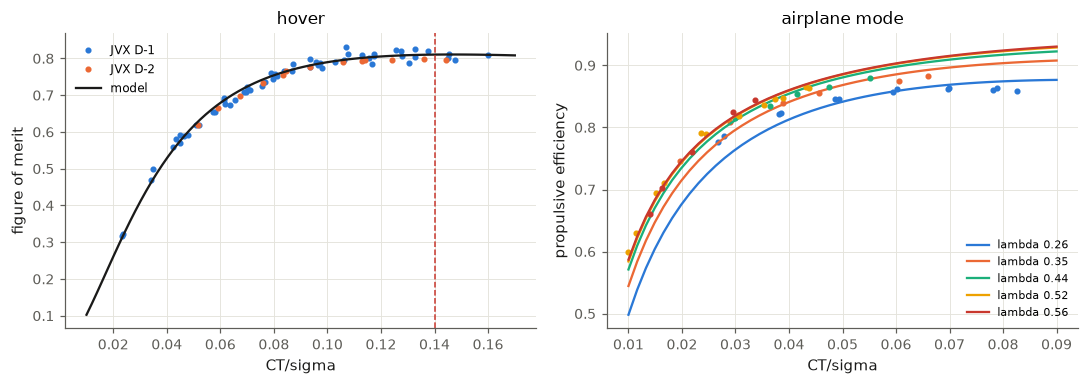

In [17]:
report = jvxcal.calibration_report()
print(f"hover FM RMS {report.hover_fm_rms:.4f}; D-2 power error max {report.hover_d2_power_error_max:.4f}")
print(f"airplane eta RMS {report.airplane_eta_rms:.4f}, max {report.airplane_eta_max:.4f}")
check("calibration metrics match the rotor.py docstring (FM RMS 0.012, eta RMS 0.013, max 0.036)",
      round(report.hover_fm_rms, 3) == 0.012 and round(report.airplane_eta_rms, 3) == 0.013
      and round(report.airplane_eta_max, 3) == 0.036)
check("D-2 (Mtip 0.73, not fitted) predicted within 3 % power (plan 016 acceptance)",
      report.hover_d2_power_error_max < 0.03)
check("predict is independent of the tip Mach used to dimensionalize (no Mach term in the model)",
      abs(jvxcal.predict(jvx, 0.1, 0.4, 0.6)[0] - jvxcal.predict(jvx, 0.1, 0.4, 0.73)[0]) < 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
loads = np.linspace(0.01, 0.17, 80)
ax = axes[0]
for table, colour in (("D-1", blue), ("D-2", orange)):
    m = np.array([t == table for t in hover_data.table])
    ax.plot(hover_data.blade_loading[m], hover_data.figure_of_merit[m], "o", ms=3, color=colour, label=f"JVX {table}")
ax.plot(loads, [jvxcal.predict(jvx, c, 0.0)[1] for c in loads], color=ink, label="model")
ax.axvline(0.14, color=red, ls="--", lw=1); ax.set_xlabel("CT/sigma"); ax.set_ylabel("figure of merit")
ax.set_title("hover"); ax.legend(fontsize=8)
ax = axes[1]
groups = sorted(set(np.round(airplane_data.advance_ratio, 2)))
colours = [blue, orange, aqua, yellow, red]
for lam_group, colour in zip([0.26, 0.35, 0.44, 0.52, 0.56], colours):
    m = np.abs(airplane_data.advance_ratio - lam_group) < 0.015
    ax.plot(airplane_data.blade_loading[m], airplane_data.efficiency[m], "o", ms=3, color=colour)
    lam_mean = float(np.mean(airplane_data.advance_ratio[m]))
    cl = np.linspace(0.01, 0.09, 50)
    ax.plot(cl, [jvxcal.predict(jvx, c, lam_mean)[1] for c in cl], color=colour, label=f"lambda {lam_mean:.2f}")
ax.set_xlabel("CT/sigma"); ax.set_ylabel("propulsive efficiency"); ax.set_title("airplane mode")
ax.legend(fontsize=7); fig.tight_layout(); plt.show()

Hover FM rises with blade loading over the whole data range (induced power grows as C_T^1.5, profile power only
through the polar). The 0.14 bound sits just below the highest test points. In airplane mode the model follows the
efficiency peak shift with λ. The largest misfits (model low by 0.034-0.036) are at light loading (C_T/σ 0.02-0.03)
and the two lowest λ groups (0.26, 0.35). Airplane-mode data reach only C_T/σ 0.083.

---
## 8. How the flight point uses the rotor (`performance/flight_point.py`)

In [18]:
show_source("src/aircraft_closure/performance/flight_point.py", 214, 231)

# src/aircraft_closure/performance/flight_point.py  lines 214-231
 214      thrust_per_rotor_N = thrust_total_N / active_rotor_count
 215      if condition.mode == "airplane":
 216          rotor_model = rotor_model.in_airplane_mode()
 217      speed_motor_limit_rad_s = motor_model.max_speed_rad_s
 218      rotor = rotor_model.evaluate(velocity_m_s, atmosphere, thrust_N=thrust_per_rotor_N, speed_rad_s=speed_rotor_rad_s)
 219      # Rotor-speed physics models (Tier 12) return blade loading and helical tip Mach to bound.
 220      if getattr(rotor_model, "blade_loading_max", None) is not None:
 221          opti.subject_to(rotor.blade_loading <= rotor_model.blade_loading_max)
 222      if getattr(rotor_model, "mach_tip_helical_max", None) is not None:
 223          opti.subject_to(rotor.mach_tip_helical <= rotor_model.mach_tip_helical_max)
 224      if condition.mode == "airplane" and getattr(rotor_model, "advance_ratio_max", None) is not None:
 225          opti.subject_to(rotor.advance

In [19]:
show_source("src/aircraft_closure/performance/flight_point.py", 393, 395)

# src/aircraft_closure/performance/flight_point.py  lines 393-395
 393      ])
 394      if rotor_model.speed_tip_max_m_s is not None:
 395          opti.subject_to(speed_rotor_rad_s * rotor_model.radius_m() <= rotor_model.speed_tip_max_m_s)


Context (C11 covers the whole file): `rotor_model = instances["propulsor"].component` (L163); rotor speed is a
fresh Opti variable at every point, lower bound 10 rad/s (L183 hover, L190 airplane); hover thrust is
T/W · W / (1 − download) (L186), airplane thrust is drag + cooling drag + W sin γ (L209).

- **L214** thrust per **active** rotor (an engine-out or rotor-out condition can change the divisor).
- **L215-216** airplane-mode points swap the model with `in_airplane_mode()`. This works for both classes: the
  momentum-profile rotor switches branch, the actuator disk swaps its coefficient.
- **L218** one call, thrust and rotor speed in. Hover passes `velocity_m_s = 0.0` (L184), so the static branch is
  consistent.
- **L220-225** the bounds, each guarded by `getattr(..., None) is not None`, so the actuator disk (which has none of
  these fields) gets no constraint, and setting a limit to `None` turns it off:
  - C_T/σ ≤ 0.14 at every point (stall margin);
  - helical tip Mach ≤ 0.80 at every point;
  - λ ≤ 0.60 in airplane mode only (in hover λ is 0).
  These are raw inequalities, not normalized margins: the quantities are already O(0.1-1).
- **L226-228** rotor power to the gearbox: Ω_motor = ratio · Ω_rotor, input torque P / (η Ω_motor).
- **L394-395** tip speed bound ΩR ≤ `speed_tip_max_m_s`, read as an attribute on both classes. In the Halo it equals
  the **design** tip speed, so no point turns the rotor faster than in hover design.
- The rotor shaft power limit is not here: it is the `propulsor power_shaft_W` margin from `compatibility.py`
  (`margin_below(ω·Q, max_shaft_power_W)`), constrained with all other margins.

**Run it: the optimum-speed rotor in cruise, and why the λ bound sets it.** Take the sized cruise point (3,048 m,
85.1 m/s), recover the thrust per rotor from the sizing's cruise power at its rotor speed, then let a small Opti
pick the rotor speed that minimizes shaft power with the flight point's bounds.

sizing cruise: V 85.13 m/s, Omega 29.362 rad/s, lambda 0.6000, P 357.1 kW/rotor
PASS  in the sized cruise the advance ratio sits on its 0.60 bound
thrust per rotor 3.692 kN
lambda bound 0.6: Omega 29.362 rad/s, P 357.1 kW, lambda 0.600, CT/sigma 0.0462
PASS  min-power rotor speed with the bounds = the sizing's cruise rotor speed (lambda bound active)
lambda bound None: Omega 16.859 rad/s, P 331.8 kW, lambda 1.045, CT/sigma 0.1400
PASS  without the lambda bound the optimizer slows the rotor until CT/sigma = 0.14 (lambda >> 0.56 data)


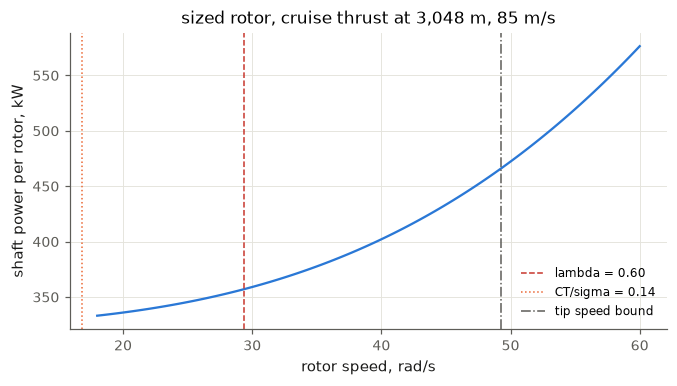

In [20]:
cruise = next(s for s in ref.segments if s["label"] == "cruise")
omega_cruise = next(w["speed_rotor_rad_s"] for w in ref.whirl_flutter if w["label"].startswith("cruise"))
V = cruise["velocity_m_s"]; atm_c = asb.Atmosphere(altitude=3048.0); R = float(rotor.radius_m())
lam_cruise = V / (omega_cruise * R)
print(f"sizing cruise: V {V:.2f} m/s, Omega {omega_cruise:.3f} rad/s, lambda {lam_cruise:.4f}, "
      f"P {cruise['power_rotors_W']/2/1e3:.1f} kW/rotor")
check("in the sized cruise the advance ratio sits on its 0.60 bound", abs(lam_cruise - 0.60) < 1e-6)

# thrust per rotor that gives the segment's power at that rotor speed (segment power is a representative value)
opti = asb.Opti(); T = opti.variable(init_guess=8e3, scale=1e3, lower_bound=0.0)
p = cruise_rotor.evaluate(V, atm_c, thrust_N=T, speed_rad_s=omega_cruise).shaft_power_W
opti.subject_to(p / 1e5 == cruise["power_rotors_W"] / 2 / 1e5)
T_cruise = float(opti.solve(verbose=False).value(T))
print(f"thrust per rotor {T_cruise/1e3:.3f} kN")

def best_speed(advance_ratio_max):
    opti = asb.Opti()
    w = opti.variable(init_guess=40.0, scale=10.0, lower_bound=10.0)
    r = cruise_rotor.evaluate(V, atm_c, thrust_N=T_cruise, speed_rad_s=w)
    opti.subject_to([r.blade_loading <= rotor.blade_loading_max, r.mach_tip_helical <= rotor.mach_tip_helical_max,
                     w * R <= rotor.speed_tip_max_m_s])
    if advance_ratio_max is not None:
        opti.subject_to(r.advance_ratio <= advance_ratio_max)
    opti.minimize(r.shaft_power_W / 1e5)
    s = opti.solve(verbose=False)
    return s.value(w), s.value(r.shaft_power_W), s.value(r.advance_ratio), s.value(r.blade_loading)

for bound in (0.60, None):
    w, P, lam, bl = best_speed(bound)
    print(f"lambda bound {bound}: Omega {w:.3f} rad/s, P {P/1e3:.1f} kW, lambda {lam:.3f}, CT/sigma {bl:.4f}")
    if bound == 0.60:
        check("min-power rotor speed with the bounds = the sizing's cruise rotor speed (lambda bound active)",
              abs(w / omega_cruise - 1) < 1e-5)
    else:
        check("without the lambda bound the optimizer slows the rotor until CT/sigma = 0.14 (lambda >> 0.56 data)",
              lam > 0.7 and abs(bl - 0.14) < 1e-6)

omegas = np.linspace(18, 60, 120)
powers = [float(cruise_rotor.evaluate(V, atm_c, thrust_N=T_cruise, speed_rad_s=w).shaft_power_W) / 1e3 for w in omegas]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(omegas, powers, color=blue)
ax.axvline(V / (0.60 * R), color=red, ls="--", lw=1, label="lambda = 0.60")
w_bl = np.sqrt(T_cruise / (float(atm_c.density()) * rotor.area_disk_m2 * rotor.solidity * 0.14)) / R
ax.axvline(w_bl, color=orange, ls=":", lw=1, label="CT/sigma = 0.14")
ax.axvline(rotor.speed_tip_max_m_s / R, color=ink_muted, ls="-.", lw=1, label="tip speed bound")
ax.set_xlabel("rotor speed, rad/s"); ax.set_ylabel("shaft power per rotor, kW")
ax.set_title("sized rotor, cruise thrust at 3,048 m, 85 m/s"); ax.legend(fontsize=8); plt.show()

Power falls monotonically as the rotor slows over the whole feasible range: profile power scales with (ΩR)³ and the
1 + 3λ² loading reference keeps the drag polar from rising. There is no interior optimum, so the optimizer goes to
the first bound it meets, λ = 0.60. This is exactly the limitation stated in `rotor.py` L22-25.

---
## 9. How `halo_sizing.py` builds the rotor

In [21]:
show_source("examples/halo_sizing.py", 171, 185)

# examples/halo_sizing.py  lines 171-185
 171  
 172  @dataclass(frozen=True)
 173  class HaloAssumptions:
 174      count_rotors: int = 2
 175      count_turbogenerators: int = 2
 176      count_blades: int = 3
 177      solidity: float = 0.089                       # XV-15
 178      speed_tip_m_s: float = 740 * u.foot           # XV-15 hover tip speed, also the bound
 179      frequency_coning_per_rev: float = 1.55        # XV-15 reading; the rotor factor calibrates it
 180      figure_of_merit: float = 0.67                 # XV-15 calibrated (Tier 10b); actuator-disk rotor only
 181      coefficient_airplane: float = 0.87            # assumed; actuator-disk rotor only
 182      # Tier 12: momentum + profile rotor calibrated on JVX (rotor speed, solidity and tip speed matter); False
 183      # restores the Tier 10c actuator disk with the two constant coefficients above.
 184      rotor_speed_physics: bool = True
 185      # Plan 017 (decided 2026-10-03): off-the-shelf turboshafts, p

In [22]:
show_source("examples/halo_sizing.py", 693, 701)

# examples/halo_sizing.py  lines 693-701
 693      power_rated_gearbox_W = (d.power_rated_gearbox_W if a.thermal_model and d.power_rated_gearbox_W is not None
 694                               else (motor.power_rated_W if lanes == 1 else lanes * motor.power_rated_W))
 695      radius_m = np.sqrt(d.area_disk_m2 / np.pi)
 696      solidity = d.solidity if d.solidity is not None else a.solidity
 697      speed_tip_m_s = d.speed_tip_m_s if d.speed_tip_m_s is not None else a.speed_tip_m_s
 698      chord_m = solidity * np.pi * radius_m / a.count_blades
 699      speed_rotor_design_rad_s = speed_tip_m_s / radius_m
 700      mass_rotors_kg = factors.rotor * afdd.mass_rotor_group_afdd82_kg(a.count_rotors, a.count_blades, radius_m, chord_m,
 701                                                                       speed_tip_m_s, a.frequency_coning_per_rev)


In [23]:
show_source("examples/halo_sizing.py", 743, 752)

# examples/halo_sizing.py  lines 743-752
 743      if a.rotor_speed_physics:
 744          rotor = MomentumProfileRotor(area_disk_m2=d.area_disk_m2, solidity=solidity, mass_kg=mass_rotors_kg / a.count_rotors,
 745                                       max_shaft_power_W=gearbox.power_rated_W * gearbox.efficiency,
 746                                       speed_tip_max_m_s=speed_tip_m_s)
 747      else:
 748          rotor = ActuatorDiskPropulsor(area_disk_m2=d.area_disk_m2, mass_kg=mass_rotors_kg / a.count_rotors,
 749                                        coefficient_of_performance=a.figure_of_merit,
 750                                        coefficient_of_performance_airplane=a.coefficient_airplane,
 751                                        max_shaft_power_W=gearbox.power_rated_W * gearbox.efficiency,
 752                                        speed_tip_max_m_s=speed_tip_m_s)


In [24]:
show_source("examples/halo_sizing.py", 1145, 1152)

# examples/halo_sizing.py  lines 1145-1152
1145          # Tier 12: solidity and design tip speed are trades; hover tip Mach bounded at sea level.
1146          speed_sound_sea_level_m_s = asb.Atmosphere(altitude=0).speed_of_sound()
1147          design = replace(design,
1148                           solidity=opti.variable(init_guess=guess.solidity if guess.solidity is not None else 0.10,
1149                                                  lower_bound=0.06, upper_bound=0.14),
1150                           speed_tip_m_s=opti.variable(
1151                               init_guess=guess.speed_tip_m_s if guess.speed_tip_m_s is not None else 220.0, scale=100.0,
1152                               lower_bound=150.0, upper_bound=a.mach_tip_hover_max * speed_sound_sea_level_m_s))


**Assumptions (L172-185).** Two rotors, three blades. σ 0.089 and tip speed 740 ft/s (225.6 m/s) are XV-15 values,
used as the fixed values when the rotor is an actuator disk. `figure_of_merit` 0.67 and `coefficient_airplane` 0.87
apply to the actuator disk only. `rotor_speed_physics=True` (L184) selects `MomentumProfileRotor`, the default since
Tier 12; `False` restores the Tier 10c actuator disk.

**Geometry and mass (L695-701).**
- **L695** R = sqrt(A/π) from the disk-area design variable.
- **L696-697** σ and design tip speed: design variables if set, else the assumptions.
- **L698** chord from solidity: σ = N_b c R / (π R²) gives c = σ π R / N_b.
- **L699** design rotor speed Ω = V_tip / R (feeds the gearbox mass and the wing frequency placement).
- **L700-701** AFDD82 rotor group mass (NDARC eq. 19-2, blades plus hubs, all rotors) × the XV-15 rotor calibration
  factor. Blade mass scales as R^1.34 c^1.00 V_tip^0.67 ν^2.53 (ν = coning frequency per rev, 1.55); hub mass on top.
  Through c = σπR/N_b the mass rises almost linearly with σ: a lower solidity is lighter, which is why the sizing
  takes σ to its lower bound 0.06 (below the JVX 0.1138 the model was fitted on, and below the XV-15's 0.089).

**The class choice (L743-752).**
- `MomentumProfileRotor(area, σ, mass per rotor, max_shaft_power = gearbox rating × gearbox efficiency,
  speed_tip_max = design tip speed)`. The calibrated drag constants, κ and the 0.14/0.80/0.60 limits stay at their
  defaults. The shaft power limit equals the gearbox output rating, the same value `compatibility.py` uses for the
  gearbox `shaft_out` envelope, so rotor and gearbox share one power limit.
- `ActuatorDiskPropulsor(area, mass, FM 0.67, airplane coefficient 0.87, same power limit, same tip speed bound)`.
  The tip speed bound still constrains the rotor speed variable, but power does not depend on it.

**Design variables (L1145-1152, only with `rotor_speed_physics`).** σ in [0.06, 0.14]; design tip speed in
[150 m/s, 0.70 a_SL] (`mach_tip_hover_max` 0.70, L202; JVX hover data were at 0.67-0.73). The disk area is a design
variable in both cases (L1127, 5-120 m²). Rotor speed is per point (flight point), bounded above by the design tip
speed through `speed_tip_max_m_s`.

In [25]:
from aircraft_closure.weights import afdd
from examples.xv15_reference import calibration_factors
factors = calibration_factors()
a = assumptions; d = ref.design
radius = np.sqrt(d.area_disk_m2 / np.pi)
chord = d.solidity * np.pi * radius / a.count_blades
mass_all = factors.rotor * afdd.mass_rotor_group_afdd82_kg(a.count_rotors, a.count_blades, radius, chord,
                                                          d.speed_tip_m_s, a.frequency_coning_per_rev)
print(f"R {radius:.3f} m, chord {chord:.4f} m, tip speed {d.speed_tip_m_s:.2f} m/s, rotor factor {factors.rotor:.4f}")
print(f"rotor group {mass_all:.1f} kg for 2 rotors -> {mass_all/2:.1f} kg per rotor (built: {float(rotor.mass_kg):.1f})")
check("AFDD82 x XV-15 factor / count reproduces the built rotor mass", abs(mass_all / 2 - float(rotor.mass_kg)) < 1e-9)
check("solidity sits at its lower bound 0.06", abs(d.solidity - 0.06) < 1e-6)
a_sl = float(asb.Atmosphere(altitude=0).speed_of_sound())
check("design tip speed sits at its upper bound 0.70 a_SL", abs(d.speed_tip_m_s / (0.70 * a_sl) - 1) < 1e-6)
gearbox = instances["gearbox"].component
check("rotor shaft power limit = gearbox rating x efficiency",
      abs(float(rotor.max_shaft_power_W) - gearbox.power_rated_W * gearbox.efficiency) < 1e-6)

# sensitivity of the rotor mass to solidity (why sigma goes to its lower bound)
for sigma in (0.06, 0.089, 0.1138):
    c = sigma * np.pi * radius / a.count_blades
    m = factors.rotor * afdd.mass_rotor_group_afdd82_kg(2, 3, radius, c, d.speed_tip_m_s, a.frequency_coning_per_rev)
    print(f"sigma {sigma:.4f}: rotor group {m:.0f} kg ({lb(m):.0f} lb)")

R 4.832 m, chord 0.3036 m, tip speed 238.21 m/s, rotor factor 0.6927
rotor group 674.9 kg for 2 rotors -> 337.4 kg per rotor (built: 337.4)
PASS  AFDD82 x XV-15 factor / count reproduces the built rotor mass
PASS  solidity sits at its lower bound 0.06
PASS  design tip speed sits at its upper bound 0.70 a_SL
PASS  rotor shaft power limit = gearbox rating x efficiency
sigma 0.0600: rotor group 675 kg (1488 lb)
sigma 0.0890: rotor group 922 kg (2033 lb)
sigma 0.1138: rotor group 1124 kg (2479 lb)


The hover cost of a low σ: C_T/σ = 0.14 fixes ρ A (ΩR)² σ = T / 0.14, so at fixed area and tip speed a lower σ means
the hover blade loading bound binds. In the sized design all three (σ lower bound, tip speed upper bound, C_T/σ =
0.14) are active together with the rotor power limit: the rotor is "as light as allowed, as fast as allowed, as
loaded as allowed".

---
## Findings

1. **Docstring points to a nonexistent argument.** `rotor.py:37`: "use `hover=True` paths for exactly zero". There is
   no `hover` parameter; the hover path is `airplane_mode=False` in `evaluate` (L112-117). At exactly λ = 0,
   `profile_integral` returns NaN (shown in section 1), so a caller that evaluates the airplane-mode branch at V = 0
   gets NaN. `trajectory/tiltrotor.py:163` avoids this with a 1e-4 m/s smoothing on the axial velocity.
2. **`RotorLimits` / `MomentumProfileRotor.get_limits()` (rotor.py:53-59, 87-89) are unused** in `src/` and
   `examples/`. The flight point reads the limit attributes with `getattr` (`flight_point.py:220-225, 394`) and the
   compatibility margins read `max_shaft_power_W` directly. Interface symmetry only.
3. **`RotorResult.power_residual_W` is always 0.0** (rotor.py:120): the momentum-profile rotor has no power-input
   mode. The field exists for shape compatibility with `PropulsorResult`.
4. **Hover branch ignores the axial velocity** for power (rotor.py:112-117) but uses it in the tip Mach (L119). A
   hover-mode call with V > 0 is silently a static rotor. The flight point always passes 0.0, so no live bug.
5. **Plan text vs code, induced power.** `docs/decisions/016` "Model" section writes induced power as
   κ C_T (λ + λ_i) − C_T λ (total C_P = κ C_T (λ + λ_i) + profile). The code (rotor.py:109) uses C_T λ + κ C_T λ_i;
   the two differ by (κ − 1) C_T λ, about 15 % of useful power. The "Progress and decisions" section of the plan
   does not record the change. The code docstring (L6) matches the code. The same plan also states JVX σ = 0.105 in
   "Assumptions", against 0.1138 in the code and the calibration script.
6. **Sized σ = 0.06 is outside the calibration solidity.** The model is in C_T/σ, so σ enters only through the
   coefficient normalization, but the JVX data are all at σ = 0.1138. The optimizer takes σ to its lower bound
   because AFDD82 blade mass is about linear in chord (section 9).
7. Minor: `jvx_rotor_calibration.py:29` opens the CSV without a context manager; `jvx_rotor(polar)` without
   `increment` raises `TypeError` at L103.

---
## Gotchas

- **Hover means static.** `MomentumProfileRotor` in hover mode sets λ = 0 regardless of the velocity passed.
- **`in_airplane_mode()` is required** for airplane-mode points; forgetting it gives the hover branch (static power,
  no useful power term C_T λ) at cruise speed.
- **Limits are attributes, enforced by the caller.** `evaluate` never clips. Setting `blade_loading_max=None` removes
  the constraint from the flight point because of the `getattr(...) is not None` guards.
- **The actuator disk's "airplane coefficient" is not propulsive efficiency**: η = coefficient · V / (V + v_i).
- **Rotor speed does not matter to the actuator disk**, but its tip speed bound is still enforced on the per-point
  rotor speed variable (flight_point.py:394-395), and the design rotor speed still sizes the gearbox.
- **Cruise rotor speed is set by λ ≤ 0.60**, not by an aerodynamic optimum (section 8). Results that depend on cruise
  rotor speed (motor torque, the wing frequency placement, gear ratio) inherit that bound.
- **Calibration constants are pasted**, not computed at import. Re-running the script after changing the data or
  the model does not update `rotor.py`; the test `test_embedded_constants_are_the_fit` catches the drift.

## Limits / what it can't do

- No blade stall, no compressibility drag rise (tip Mach 0.58-0.73 data only), no Reynolds effect.
- Axial flow only: no edgewise (conversion) aerodynamics. The trajectory model uses V cos(φ) as axial velocity and
  blends κ and the increment with cos²(tilt) (`trajectory/tiltrotor.py:150-163`).
- No swirl, tip loss or twist distribution as separate terms (folded into κ and the increment).
- No windmilling, autorotation or vortex ring state (momentum theory, V ≥ 0).
- One calibration rotor (JVX). σ, twist and airfoil changes are not represented beyond the C_T/σ normalization.

## What's next (from `docs/decisions/016`, "Deferred")

BEM with a twist distribution (with stall, the remedy for the λ bound), compressibility drag divergence, swirl and tip
loss as separate terms, and an edgewise conversion-mode rotor (Tier 20/22).

## Review questions

<details><summary>Why does the hover branch not call profile_integral(0)?</summary>

The closed form contains λ⁴ ln((1 + sqrt(1 + λ²))/λ). At λ = 0 that is 0 · ∞ = NaN in floating point (and an
undefined derivative in CasADi), although the limit is 0 and I(0) = 1/4. The hover branch writes σ/8 · c_d directly
(rotor.py:117).
</details>

<details><summary>What does the 1 + 3λ² in section_drag do, and what side effect does it have?</summary>

It refers the blade loading C_T/σ to the mean section dynamic pressure, which grows with λ because each section sees
sqrt((Ωr)² + V²). That lets one drag polar serve hover and airplane mode. Side effect: at large λ a heavily loaded
blade looks lightly loaded, so the model has no drag rise when the rotor slows. Cruise power keeps falling with rotor
speed, and only the λ ≤ 0.60 bound (and C_T/σ ≤ 0.14) stops the optimizer.
</details>

<details><summary>Why is κ fixed at 1.15 rather than fitted?</summary>

With κ free, the induced column x^1.5 is nearly a linear combination of the polar columns [1, x, x²] over C_T/σ
0.02-0.16, so the fit trades κ against d0, d1, d2 and lands on κ < 1 (section 6 reproduces it), which is unphysical
(κ ≥ 1 by definition: uniform inflow is the minimum induced power). Fixing κ at a standard hover value makes the fit
linear and well posed.
</details>

<details><summary>Derive the actuator disk's rationalized induced velocity and say why it is used.</summary>

From T = 2 ρ A v_i (V + v_i): v_i = −V/2 + sqrt(V²/4 + T/(2ρA)). Multiply by the conjugate: v_i = T / (ρ A (V +
sqrt(V² + 2T/(ρA)))). The textbook form subtracts two nearly equal numbers when V ≫ v_i (cruise), losing precision;
the rationalized form adds positive numbers only. The only singularity is T = V = 0, protected with `np.where` there
only (propulsor.py:69).
</details>

<details><summary>Which limits does the flight point enforce on the rotor at each point, and where?</summary>

C_T/σ ≤ 0.14 and helical tip Mach ≤ 0.80 at every point (flight_point.py:220-223); λ ≤ 0.60 in airplane mode
(L224-225); ΩR ≤ `speed_tip_max_m_s` = the design tip speed (L394-395). The shaft power limit (gearbox rating × η) is
a compatibility margin (`compatibility.py`, `propulsor power_shaft_W`). Rotor speed has a lower bound of 10 rad/s as
a variable bound (L183, L190).
</details>

<details><summary>Why does the sized Halo end at σ = 0.06 and tip speed 0.70 a_SL?</summary>

AFDD82 blade mass is about linear in chord, and chord = σπR/N_b, so lower σ is lighter. Lower σ raises C_T/σ in
hover; to keep C_T/σ ≤ 0.14 the rotor must spin faster (C_T ∝ 1/(ΩR)²), up to the tip speed bound 0.70 a_SL. Both
bounds and the blade-loading limit are active at the hover requirement point (section 3).
</details>

In [26]:
check_summary()

35 of 35 checks passed
